In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import emcee
import corner
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

# part 1

## dataset

In [2]:
#collecting data
file = np.load("transient.npy")
#columns are: time, flux, uncertainties
time = file[:, 0]
flux = file[:, 1]
errors = file[:, 2]

Text(0, 0.5, 'flux')

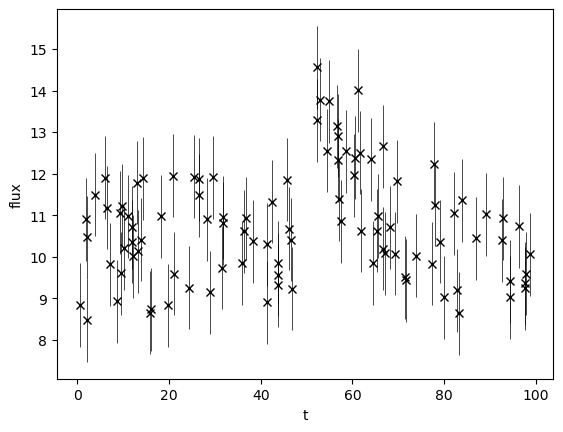

In [3]:
plt.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x")
plt.xlabel("t")
plt.ylabel("flux")

---
**model: burst**

$
f(t) =
\begin{cases}
    b & t<t_0 \\
    b + Ae^{-\alpha(t-t_0)} & t\geq t_0
   \end{cases}
$

- $b$ is the background amplitude
- $A$ is the burst amplitude
- $t_0$ is the burst epoch, the beginning
- $\alpha$ is how rapidly the burst disappears
---

In [4]:
def burst(par, t): #par = [b, A, t_0, alpha]
    f = np.empty(len(t))
    b, A, t_0, alpha = par
    mask = t>t_0 #where burst begins
    f[mask] = b+A*np.exp(-alpha*(t[mask]-t_0))
    f[~mask] = b #here no burst, just background
    return f

In [5]:
def log_likelihood(par, t, flux, err, model):
    lL = np.sum(((flux-model(par, t))/err)**2)
    return -lL/2

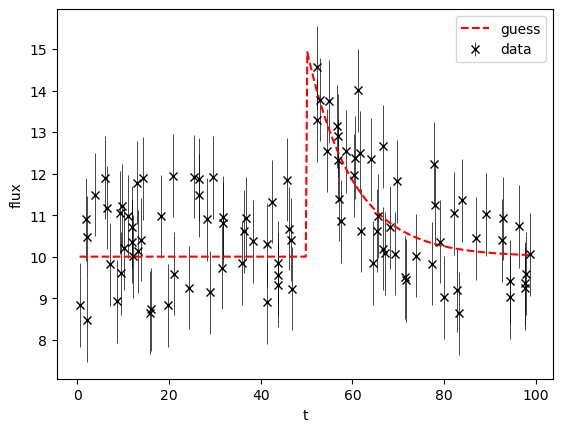

In [6]:
#just to have an idea about the initial guesses
b_guess = 10
A_guess = 5
t_0_guess = 50
alpha_guess = 0.1
par_guesses = [b_guess, A_guess, t_0_guess, alpha_guess]

x = np.linspace(min(time), max(time), 3*len(time))
y = burst(par_guesses, x)

plt.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
plt.plot(x, y, "--r", label="guess")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()

In [7]:
log_likelihood(par_guesses, time, flux, errors, burst)

-51.488086205373705

## MCMC

**priors**

- $b \in \mathrm{Uniform}[0,50]$
- $A \in \mathrm{Uniform}[0,50]$
- $t_0 \in \mathrm{Uniform}[0,100]$
- $\ln\alpha \in \mathrm{Uniform}[-5,5]$

for the log uniform: $p(y) = |\frac{dx}{dy}|p(x)$

$x = \ln\alpha$

$y = e^x = \alpha$

$|\frac{dx}{dy}|=|\frac{d\ln\alpha}{d\alpha}|=\frac{1}{\alpha}$

$p(x) = 1/10$ for $x$ in $[-5, 5]$

$p(y) = p(\alpha) = |\frac{dx}{dy}| p(x) = \frac{1}{10\alpha}$ for $\alpha$ in $[e^{-5}, e^5]$

getting only the proportionality is ok because here the normalised evidence is not necessary, just the ratio of evidences for the Bayes Factor

In [8]:
#limits for the prior
b_min, b_max = 0, 50
A_min, A_max = 0, 50
t_0_min, t_0_max = 0, 100
alpha_min, alpha_max = np.exp(-5), np.exp(5)

def log_prior(par):
    b, A, t_0, alpha = par
    if b_min < b < b_max and A_min < A < A_max and t_0_min < t_0 < t_0_max and alpha_min < alpha < alpha_max:
        return -np.log(alpha) # = log(alpha^-1)... the other ones are constants
    return -np.inf # = log(0)

def log_posterior(par, t, flux, err, model):
    return log_likelihood(par, t, flux, err, model)+log_prior(par)

In [9]:
N_dim = 4 #number model parameters
N_walkers = 10
burn_in = 10000
N_steps = 100000 #for each walker

guesses = par_guesses+np.random.random((N_walkers, N_dim))

sampler = emcee.EnsembleSampler(N_walkers, N_dim, log_posterior, args=[time, flux, errors, burst])
sampler.run_mcmc(guesses, N_steps)

samples = sampler.get_chain() #shape: N_steps, N_walkers, N_dim

Text(0.5, 0.98, 'trace plots with burn-in period')

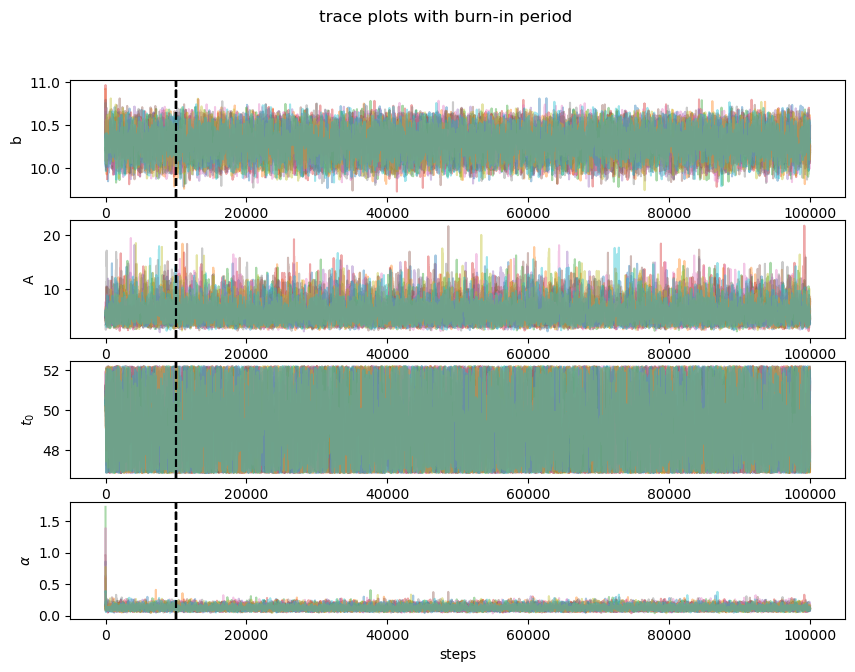

In [10]:
fig = plt.figure(figsize=(10, 7))
pos = [411, 412, 413, 414]
labels = ["b", "A", "$t_0$", "$\\alpha$"]

for i in range(N_dim):
    ax = fig.add_subplot(pos[i])
    for j in range(N_walkers):
        ax.plot(samples[:, j, i], alpha=0.4)
        ax.axvline(burn_in, ls="--", color="k")
        ax.set_ylabel(labels[i])
ax.set_xlabel("steps")
fig.suptitle("trace plots with burn-in period")

Text(0.5, 0.98, 'trace plots for all walkers')

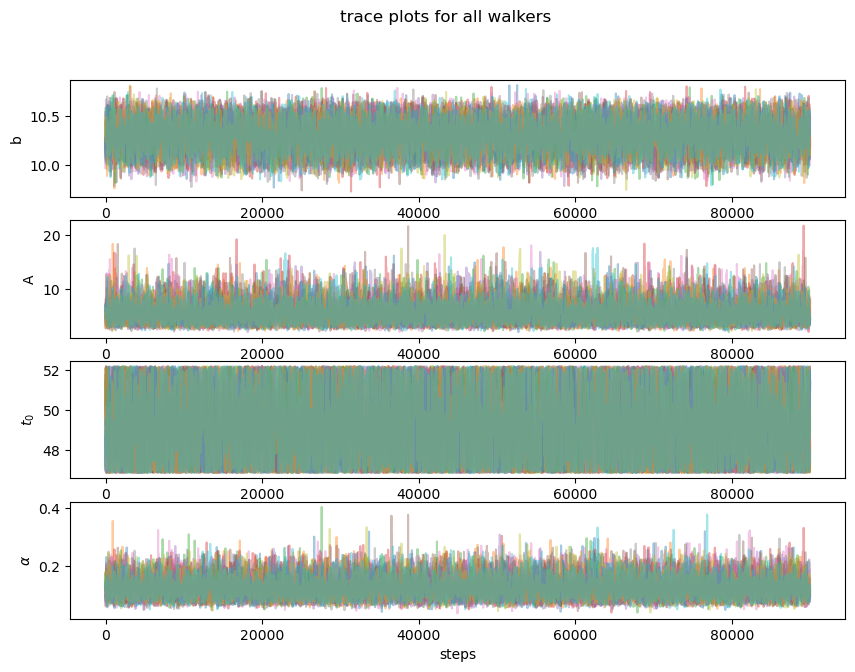

In [11]:
samples = sampler.get_chain(discard=burn_in) #shape: N_steps-burn-in, N_walkers, N_dim

fig = plt.figure(figsize=(10, 7))
pos = [411, 412, 413, 414]

for i in range(N_dim):
    ax = fig.add_subplot(pos[i])
    for j in range(N_walkers):
        ax.plot(samples[:, j, i], alpha=0.4)
        ax.set_ylabel(labels[i])

ax.set_xlabel("steps")
fig.suptitle("trace plots for all walkers")

Text(0.5, 0.98, 'trace plots with flattened samples')

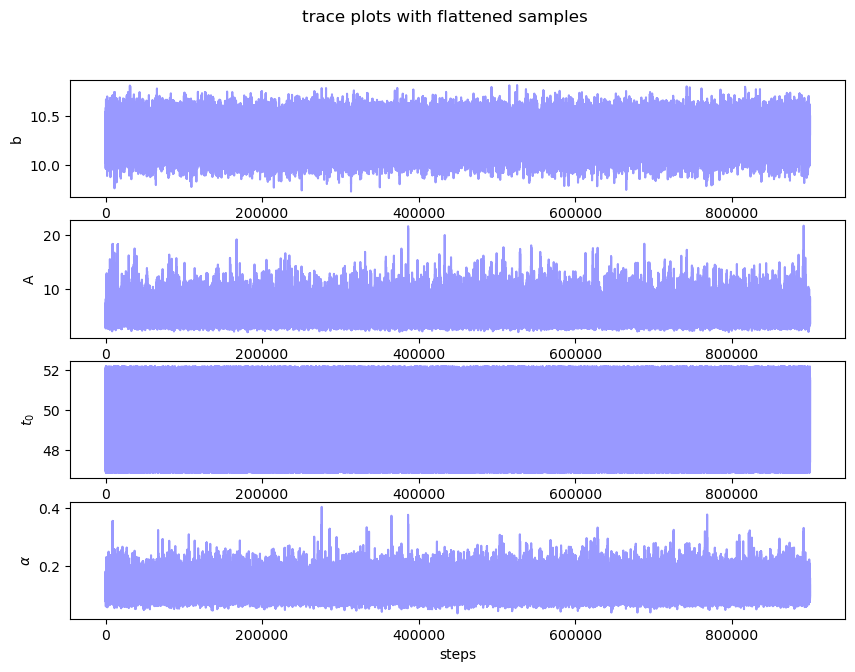

In [12]:
samples = samples.reshape(-1, N_dim) #reshaped into the remaining dimensions and N_dim to get all the samples for each dim

fig = plt.figure(figsize=(10, 7))


for i in range(N_dim):
    ax = fig.add_subplot(pos[i])
    ax.plot(samples[:, i], "b", alpha=0.4)
    ax.set_ylabel(labels[i])

ax.set_xlabel("steps")
fig.suptitle("trace plots with flattened samples")

Text(0.5, 0.98, 'thinned trace plots')

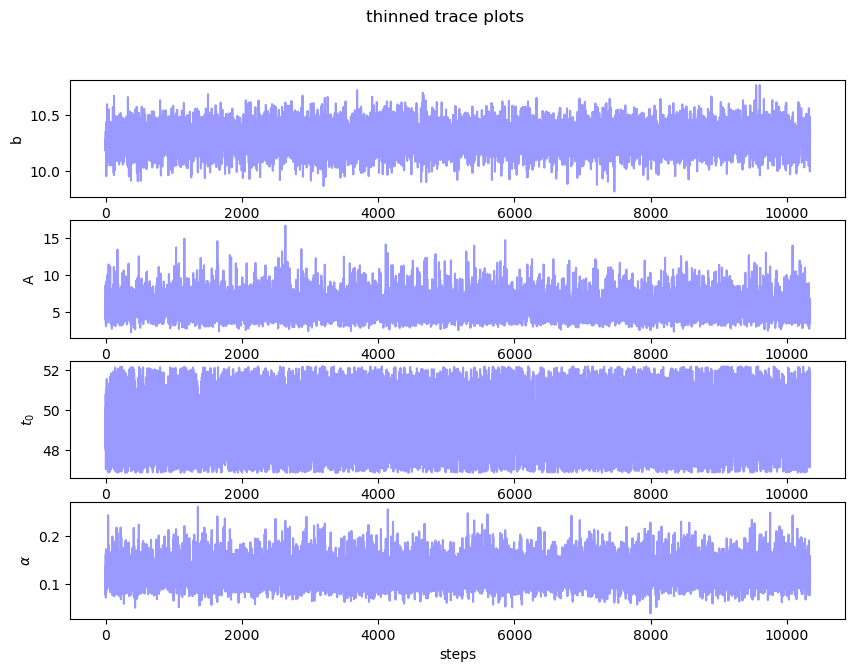

In [13]:
#thinning
tau = sampler.get_autocorr_time()
samples = sampler.get_chain(discard=burn_in, thin=int(max(tau)), flat=True)

fig = plt.figure(figsize=(10, 7))

for i in range(N_dim):
    ax = fig.add_subplot(pos[i])
    ax.plot(samples[:, i], "b", alpha=0.4)
    ax.set_ylabel(labels[i])

ax.set_xlabel("steps")
fig.suptitle("thinned trace plots")

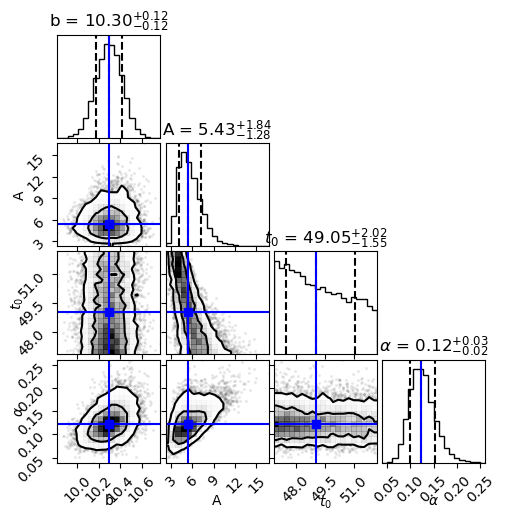

In [14]:
#corner plots
b_median = np.median(samples[:, 0])
A_median = np.median(samples[:, 1])
t_0_median = np.median(samples[:, 2])
alpha_median = np.median(samples[:, 3])

fig = plt.figure(figsize=(5, 5))
c = corner.corner(samples, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], truths=[b_median, A_median, t_0_median, alpha_median], truth_color="b", show_titles=True, fig=fig)

## watching results

In [15]:
#picking randomly some models to look at
some_models = np.array([np.random.choice(samples[:, i], 100, replace=False) for i in range(N_dim)])

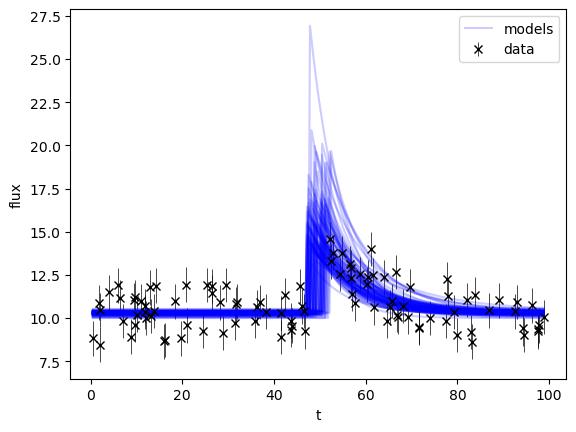

In [16]:
plt.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
for i in range(100):
    plt.plot(x, burst(some_models[:, i], x), "b", alpha=0.2)
plt.plot(x, burst(some_models[:, i], x), "b", alpha=0.2, label="models")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()

In [17]:
results = np.quantile(samples, [0.05, 0.50, 0.95], axis=0) #4 columns are parameters, 3 rows are percentiles
parameters = ["b", "A", "t_0", "alpha"]
for l, r in zip(parameters, results.T):
    print(l+"\n"+"median: "+str(r[1])+"\n90% credible region: -"+str(r[1]-r[0])+"  +"+str(r[2]-r[1])+"\n")

b
median: 10.29724988951012
90% credible region: -0.20186316122407177  +0.19578597652337137

A
median: 5.428146866759514
90% credible region: -1.8669609248486188  +3.2576976883217963

t_0
median: 49.05286942094787
90% credible region: -1.9915765552266862  +2.739498456653436

alpha
median: 0.12284167211752879
90% credible region: -0.0376201983006863  +0.05181259281923285



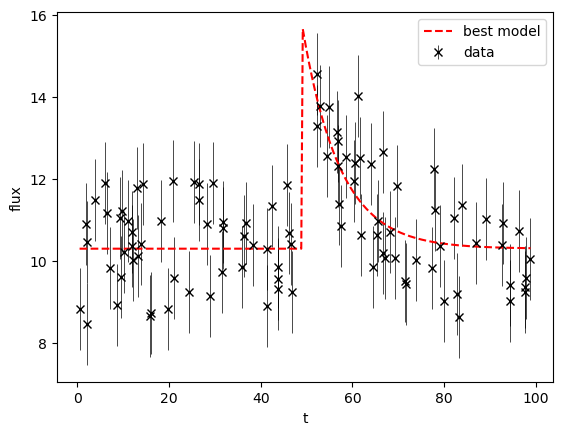

In [18]:
plt.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
plt.plot(x, burst(results[1, :], x), "--r", label="best model")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()

# part 2

## dynesty

In [19]:
#log likelihood is the same as before

#transforming from unit hypercube to prior
def prior_1cube(u):
    priors = np.zeros(len(u)) #one dimension for each parameter
    #with percent point function: given a number in cdf [0, 1], gets the corresponding parameter value
    priors[0] = stats.uniform.ppf(u[0], loc=b_min, scale=b_max-b_min)
    priors[1] = stats.uniform.ppf(u[1], loc=A_min, scale=A_max-A_min)
    priors[2] = stats.uniform.ppf(u[2], loc=t_0_min, scale=t_0_max-t_0_min)
    priors[3] = stats.loguniform.ppf(u[3], alpha_min, alpha_max)
    return priors

In [ ]:
#as before
sampler_d = dynesty.NestedSampler(log_likelihood, prior_1cube, N_dim, logl_args=[time, flux, errors, burst], nlive=300)
sampler_d.run_nested()
results_d = sampler_d.results

  6%| | 2389/37859 [02:56<4:14:25,  2.32it/s, bound: 136 | nc: 113 | ncall: 68458 | eff(%):  3.490 | loglstar: -86.407 C:\Users\giuli\anaconda3\Lib\site-packages\dynesty\bounding.py:706: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
 12%| | 2485/19938 [03:07<37:22,  7.78it/s, bound: 146 | nc: 58 | ncall: 72157 | eff(%):  3.444 | loglstar: -84.149 | lC:\Users\giuli\anaconda3\Lib\site-packages\dynesty\bounding.py:706: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very comp

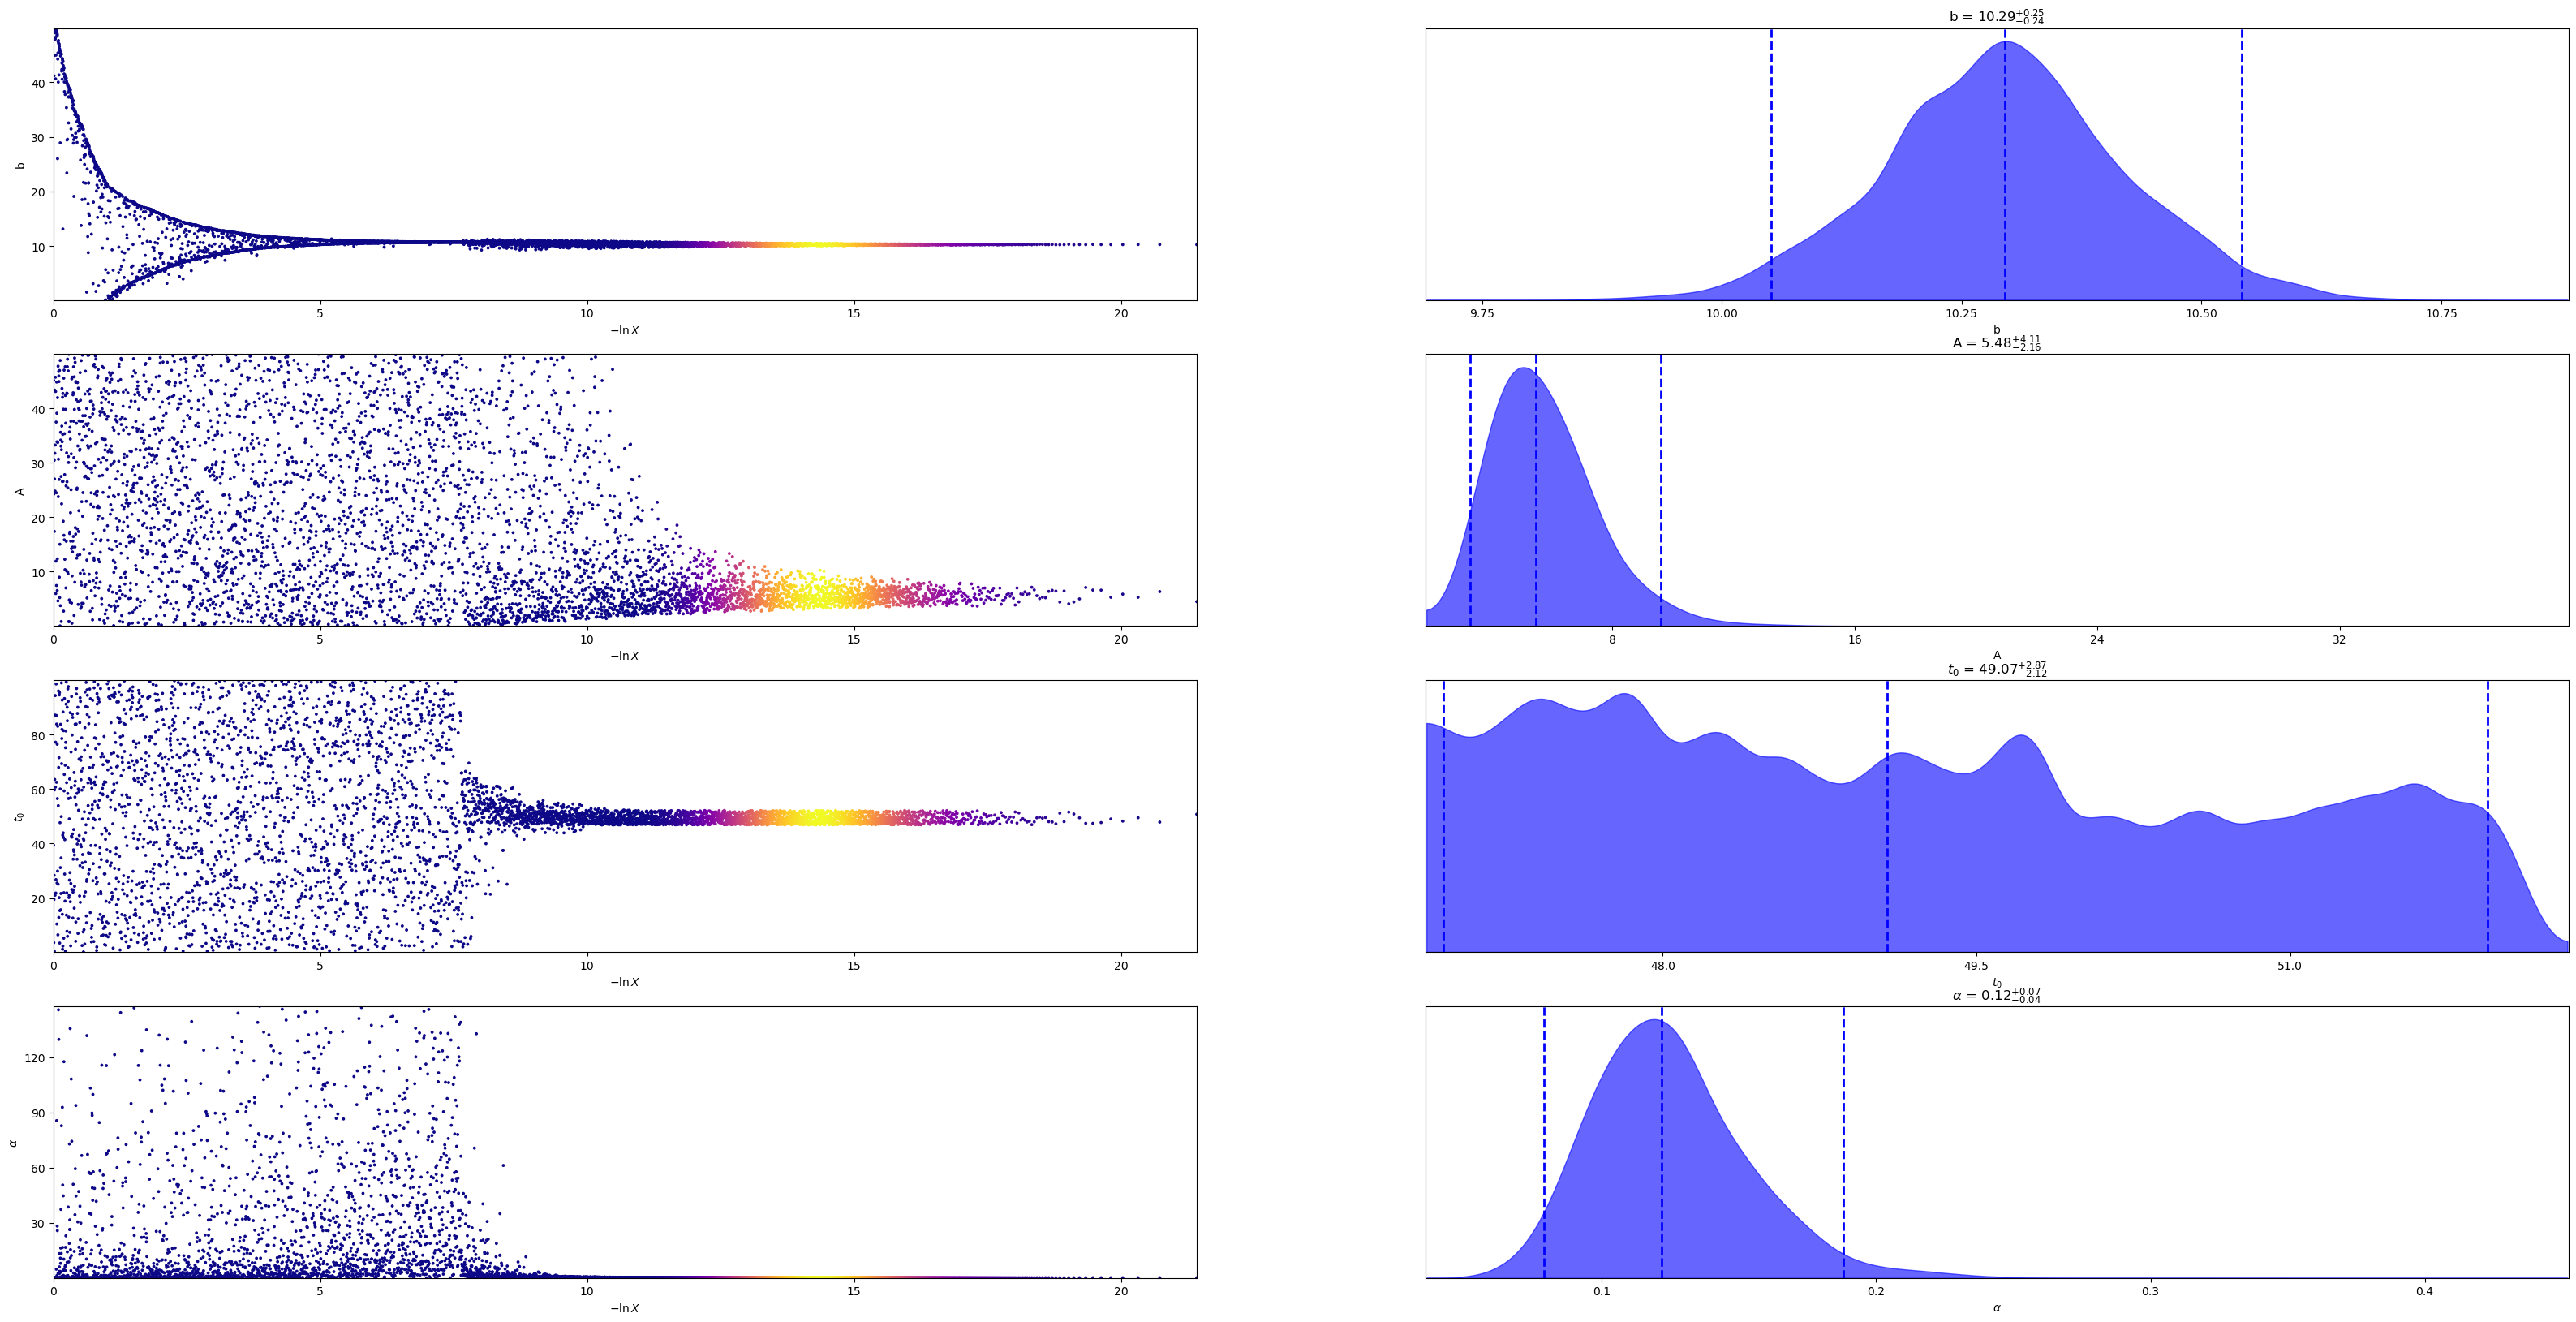

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(40, 20))
fig, axes = dyplot.traceplot(results_d, show_titles=True, labels=labels, fig=(fig, axes))

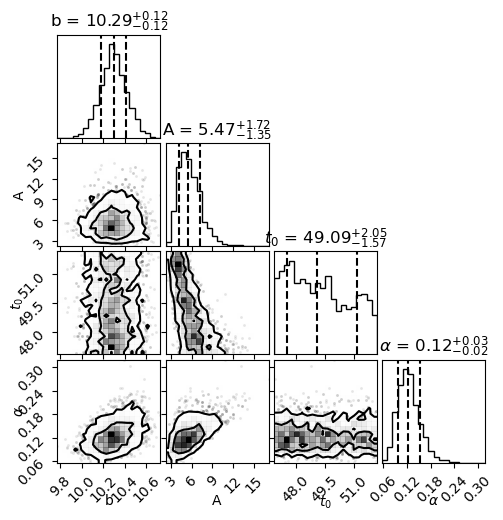

In [23]:
samples_d = results_d.samples
weights_d = np.exp(results_d.logwt-results_d.logz[-1]) #normalised with the evidence

samples_equal_d = dyfunc.resample_equal(samples_d, weights_d)

fig = plt.figure(figsize=(5, 5))
c = corner.corner(samples_equal_d, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True, fig=fig)

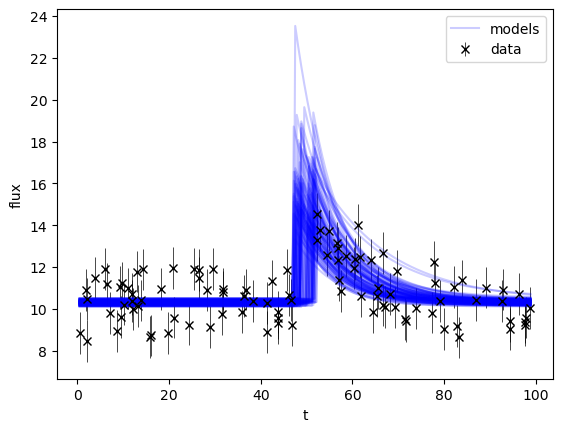

In [24]:
some_models_d = np.array([np.random.choice(samples_equal_d[:, i], 100, replace=False) for i in range(N_dim)])

plt.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
for i in range(100):
    plt.plot(x, burst(some_models_d[:, i], x), "b", alpha=0.2)
plt.plot(x, burst(some_models_d[:, i], x), "b", alpha=0.2, label="models")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()

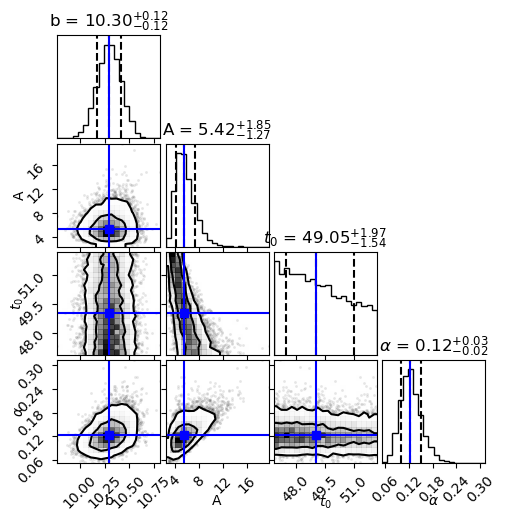

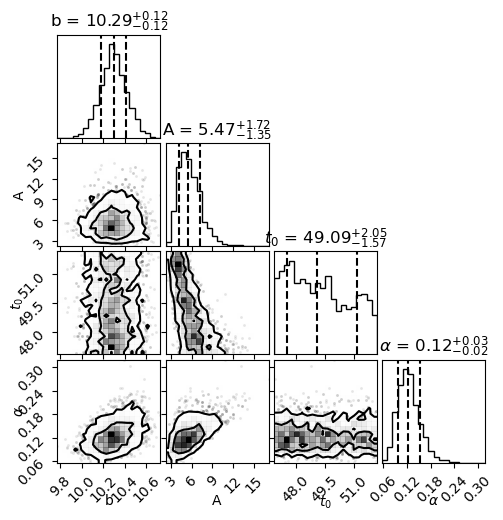

In [25]:
#comparing...
fig1 = plt.figure(1, figsize=(5, 5))
c1 = corner.corner(samples, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], truths=[b_median, A_median, t_0_median, alpha_median], truth_color="b", show_titles=True, fig=fig1)
fig2 = plt.figure(2, figsize=(5, 5))
c2 = corner.corner(samples_equal_d, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True, fig=fig2)

ok they look similar!

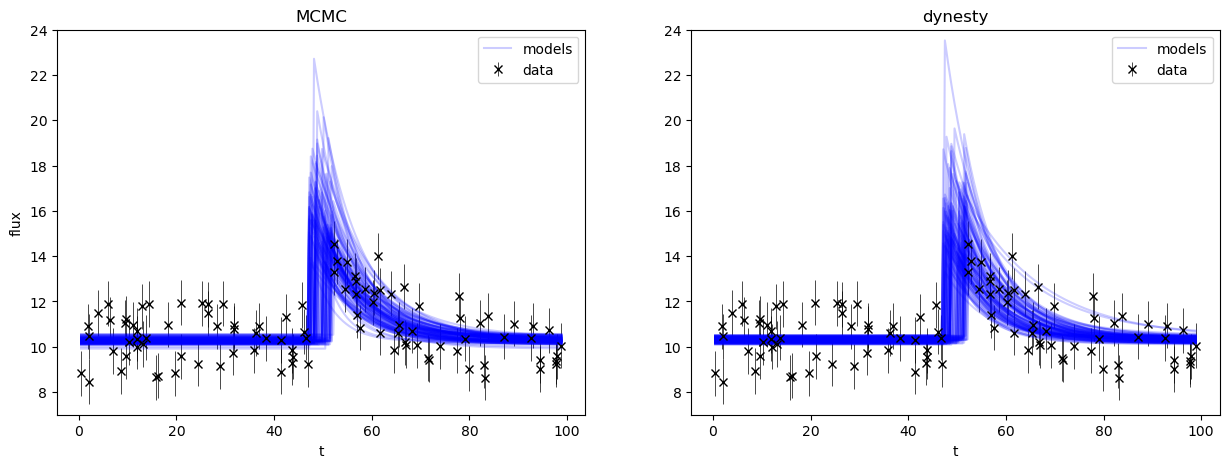

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
axes[1].errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
for i in range(100):
    axes[0].plot(x, burst(some_models[:, i], x), "b", alpha=0.2)
    axes[1].plot(x, burst(some_models_d[:, i], x), "b", alpha=0.2)
axes[0].plot(x, burst(some_models[:, i], x), "b", alpha=0.2, label="models")
axes[0].set_xlabel("t")
axes[0].set_ylabel("flux")
axes[0].set_ylim(7, 24)
axes[0].set_title("MCMC")
axes[0].legend()
axes[1].plot(x, burst(some_models_d[:, i], x), "b", alpha=0.2, label="models")
axes[1].set_xlabel("t")
axes[1].set_ylim(7, 24)
axes[1].set_title("dynesty")
axes[1].legend()

## Gaussian model

now the model of the signal is $y = b + Ae^{-\frac{(t-t_0)^2}{2\sigma^2}}$

In [27]:
def Gaussian_signal(par, t): #par = [b, A, t_0, sigma]
    b, A, t_0, sigma = par
    return b+A*np.exp(-((t-t_0)**2)/(2*sigma**2))

and the priors are the same as before, but $\sigma$ is going to be log uniform in [-1, 4], as:
- when $\sigma<e^{-1}$, the Gaussian becomes too small
- when $\sigma>e^{4}$, the Gaussian goes over the data

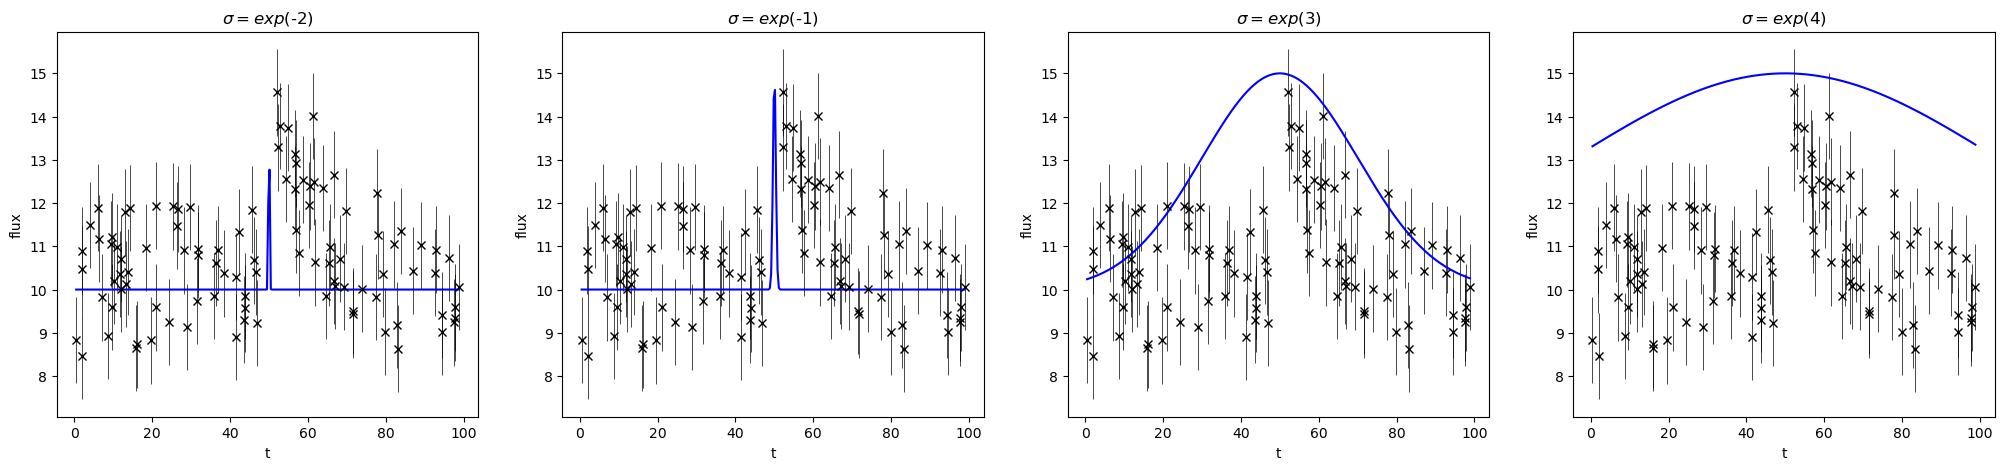

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(25, 5))
log_sigma = np.array([-2, -1, 3, 4])
sigmas = np.exp(log_sigma)
for i in range(len(sigmas)):
    ax = axes[i]
    ax.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x")
    pars = [b_guess, A_guess, t_0_guess, sigmas[i]]
    ax.plot(x, Gaussian_signal(pars, x), "b")
    ax.set_xlabel("t")
    ax.set_ylabel("flux")
    ax.set_title("$\\sigma=exp($"+str(log_sigma[i])+")")

In [29]:
sigma_min, sigma_max = np.exp(-1), np.exp(4)

def prior_1cube_G(u):
    priors = np.zeros(len(u)) #one dimension for each parameter
    #with percent point function: given a number in cdf [0, 1], gets the corresponding parameter value
    priors[0] = stats.uniform.ppf(u[0], loc=b_min, scale=b_max-b_min)
    priors[1] = stats.uniform.ppf(u[1], loc=A_min, scale=A_max-A_min)
    priors[2] = stats.uniform.ppf(u[2], loc=t_0_min, scale=t_0_max-t_0_min)
    priors[3] = stats.loguniform.ppf(u[3], sigma_min, sigma_max)
    return priors

In [30]:
sampler_G = dynesty.NestedSampler(log_likelihood, prior_1cube_G, N_dim, logl_args=[time, flux, errors, Gaussian_signal], nlive=300)
sampler_G.run_nested()
results_G = sampler_G.results

 35%|▎| 1956/5630 [00:32<07:31,  8.14it/s, bound: 35 | nc: 122 | ncall: 21908 | eff(%):  8.928 | loglstar: -101.461 | lC:\Users\giuli\anaconda3\Lib\site-packages\dynesty\bounding.py:706: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
 31%|▎| 2072/6587 [00:41<03:17, 22.84it/s, bound: 48 | nc: 29 | ncall: 26801 | eff(%):  7.731 | loglstar: -95.560 | logC:\Users\giuli\anaconda3\Lib\site-packages\dynesty\bounding.py:706: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very comp

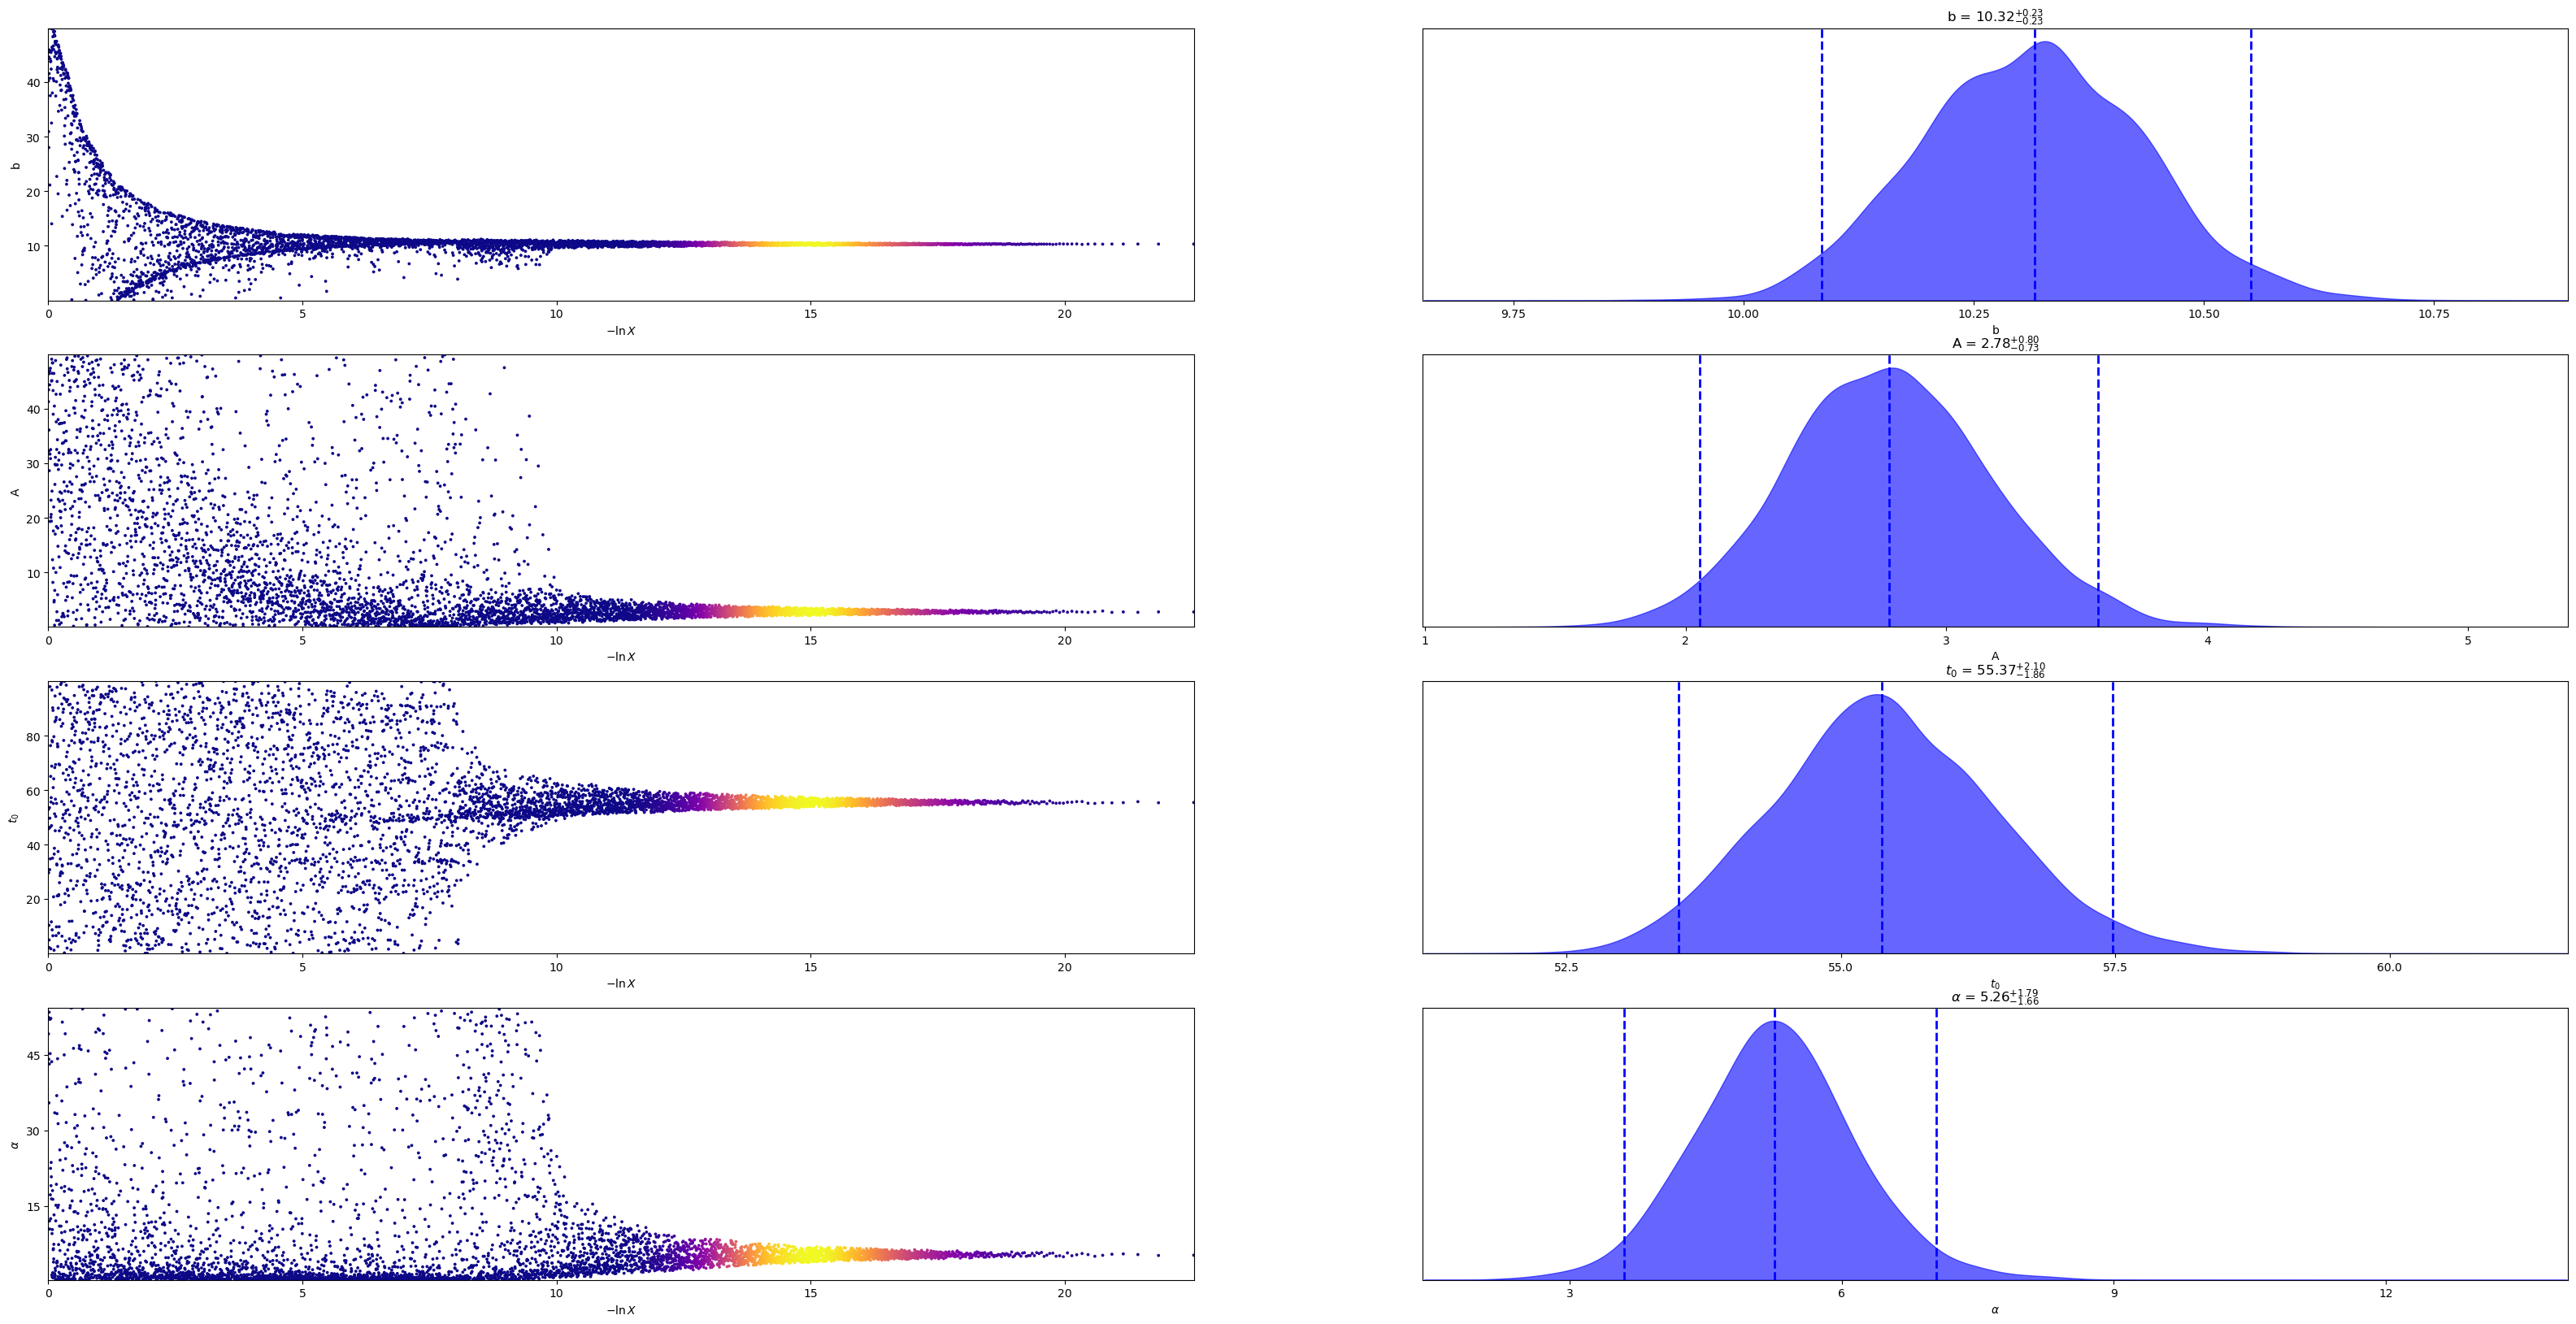

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(40, 20))
fig, axes = dyplot.traceplot(results_G, show_titles=True, labels=labels, fig=(fig, axes))

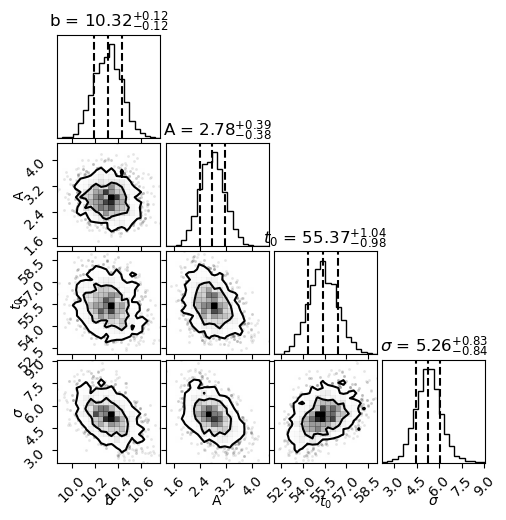

In [32]:
samples_G = results_G.samples
weights_G = np.exp(results_G.logwt-results_G.logz[-1])

labels_G = ["b", "A", "$t_0$", "$\\sigma$"]
samples_equal_G = dyfunc.resample_equal(samples_G, weights_G)

fig = plt.figure(figsize=(5, 5))
c = corner.corner(samples_equal_G, labels=labels_G, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True, fig=fig)

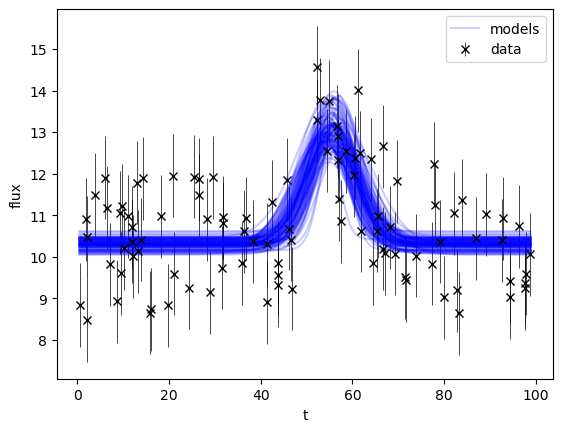

In [33]:
some_models_G = np.array([np.random.choice(samples_equal_G[:, i], 100, replace=False) for i in range(N_dim)])

plt.errorbar(time, flux, yerr=errors, linestyle="none", color="black", linewidth=0.5, marker="x", label="data")
for i in range(100):
    plt.plot(x, Gaussian_signal(some_models_G[:, i], x), "b", alpha=0.2)
plt.plot(x, Gaussian_signal(some_models_G[:, i], x), "b", alpha=0.2, label="models")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()

In [34]:
#Bayes Factor
print("Bayes Factor between burst and Gaussian models: ", np.exp(results_d.logz[-1])/np.exp(results_G.logz[-1]))

Bayes Factor between burst and Gaussian models:  123.17942203410621


burst model is favoured!